# Task 2 – Connect Four AI

**Objetivo:** Construir una IA que juegue Connect Four (4 en línea) a nivel competitivo.

Reglas:
- Tablero de **7 columnas × 6 filas**
- Gana quien conecte **4 fichas consecutivas** (horizontal, vertical o diagonal)
- Juego de suma cero: Ganar (+1000), Perder (−1000), Empate (0)

---
## Task 2.1 – Lógica del juego y Minimax base

In [12]:
import numpy as np
import random
import time
import copy
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output

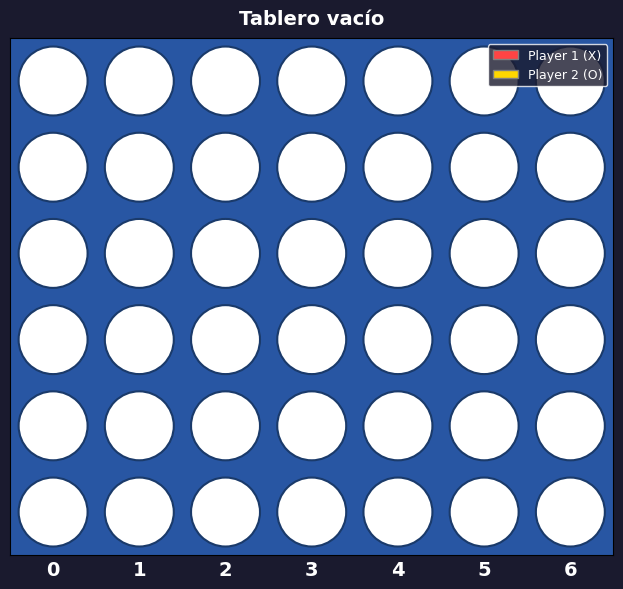

Movimientos válidos: [0, 1, 2, 3, 4, 5, 6]
¿Es terminal?: False


In [13]:
class Connect4:
    """Clase que maneja el estado del tablero de Connect Four."""

    ROWS = 6
    COLS = 7
    EMPTY = 0
    PLAYER1 = 1  # Jugador humano / agente 1
    PLAYER2 = 2  # IA / agente 2

    def __init__(self):
        self.board = np.zeros((self.ROWS, self.COLS), dtype=int)
        self.current_player = self.PLAYER1

    def copy(self):
        """Retorna una copia profunda del estado."""
        new_game = Connect4()
        new_game.board = self.board.copy()
        new_game.current_player = self.current_player
        return new_game

    def actions(self):
        """Retorna lista de columnas válidas donde se puede soltar ficha."""
        return [col for col in range(self.COLS) if self.board[0][col] == self.EMPTY]

    def drop_piece(self, col):
        """Coloca ficha del jugador actual en la columna dada. Retorna la fila donde cayó."""
        for row in range(self.ROWS - 1, -1, -1):
            if self.board[row][col] == self.EMPTY:
                self.board[row][col] = self.current_player
                self.current_player = self.PLAYER2 if self.current_player == self.PLAYER1 else self.PLAYER1
                return row
        return -1  # Columna llena (no debería pasar si se valida con actions())

    def undo_move(self, col, row):
        """Deshace un movimiento (para eficiencia en búsqueda)."""
        self.board[row][col] = self.EMPTY
        self.current_player = self.PLAYER2 if self.current_player == self.PLAYER1 else self.PLAYER1

    def check_winner(self, player):
        """Verifica si un jugador ha ganado (4 en línea)."""
        b = self.board
        # Horizontal
        for r in range(self.ROWS):
            for c in range(self.COLS - 3):
                if b[r][c] == b[r][c+1] == b[r][c+2] == b[r][c+3] == player:
                    return True
        # Vertical
        for r in range(self.ROWS - 3):
            for c in range(self.COLS):
                if b[r][c] == b[r+1][c] == b[r+2][c] == b[r+3][c] == player:
                    return True
        # Diagonal ↘
        for r in range(self.ROWS - 3):
            for c in range(self.COLS - 3):
                if b[r][c] == b[r+1][c+1] == b[r+2][c+2] == b[r+3][c+3] == player:
                    return True
        # Diagonal ↗
        for r in range(3, self.ROWS):
            for c in range(self.COLS - 3):
                if b[r][c] == b[r-1][c+1] == b[r-2][c+2] == b[r-3][c+3] == player:
                    return True
        return False

    def is_terminal(self):
        """Retorna True si el juego terminó (victoria o empate)."""
        if self.check_winner(self.PLAYER1):
            return True
        if self.check_winner(self.PLAYER2):
            return True
        if len(self.actions()) == 0:
            return True
        return False

    def get_terminal_score(self, ai_player):
        """Retorna puntaje terminal: +1000 si gana la IA, -1000 si pierde, 0 empate."""
        opponent = self.PLAYER1 if ai_player == self.PLAYER2 else self.PLAYER2
        if self.check_winner(ai_player):
            return 1000
        if self.check_winner(opponent):
            return -1000
        return 0  # Empate

    def print_board(self):
        """Imprime el tablero en consola de forma visual (texto)."""
        symbols = {self.EMPTY: '.', self.PLAYER1: 'X', self.PLAYER2: 'O'}
        print()
        for row in self.board:
            print(' '.join(symbols[cell] for cell in row))
        print(' '.join(str(i) for i in range(self.COLS)))
        print()

    def display_board(self, title="", last_move=None):
        """Dibuja el tablero gráficamente con matplotlib (estilo Connect Four real)."""
        colors = {
            self.EMPTY: 'white',
            self.PLAYER1: '#FF4444',   # Rojo para Player 1 (X)
            self.PLAYER2: '#FFD700',   # Amarillo para Player 2 (O)
        }

        fig, ax = plt.subplots(1, 1, figsize=(7, 6))
        # Fondo azul del tablero
        ax.set_facecolor('#2856A3')
        fig.patch.set_facecolor('#1a1a2e')

        for r in range(self.ROWS):
            for c in range(self.COLS):
                piece = self.board[r][c]
                color = colors[piece]
                # Borde resaltado si es la última jugada
                edge_color = '#00FF00' if last_move and last_move == (r, c) else '#1a3a6a'
                edge_width = 3 if last_move and last_move == (r, c) else 1.5
                circle = plt.Circle((c, self.ROWS - 1 - r), 0.4,
                                    facecolor=color, edgecolor=edge_color, linewidth=edge_width)
                ax.add_patch(circle)

        ax.set_xlim(-0.5, self.COLS - 0.5)
        ax.set_ylim(-0.5, self.ROWS - 0.5)
        ax.set_aspect('equal')
        ax.set_xticks(range(self.COLS))
        ax.set_xticklabels(range(self.COLS), fontsize=14, fontweight='bold', color='white')
        ax.set_yticks([])
        ax.tick_params(axis='x', colors='white', length=0)

        # Leyenda
        legend_elements = [
            patches.Patch(facecolor='#FF4444', edgecolor='gray', label='Player 1 (X)'),
            patches.Patch(facecolor='#FFD700', edgecolor='gray', label='Player 2 (O)'),
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=9,
                  facecolor='#1a1a2e', edgecolor='white', labelcolor='white')

        if title:
            ax.set_title(title, fontsize=14, fontweight='bold', color='white', pad=10)

        plt.tight_layout()
        plt.show()


# --- Prueba rápida de la clase ---
game = Connect4()
game.display_board(title="Tablero vacío")
print(f"Movimientos válidos: {game.actions()}")
print(f"¿Es terminal?: {game.is_terminal()}")

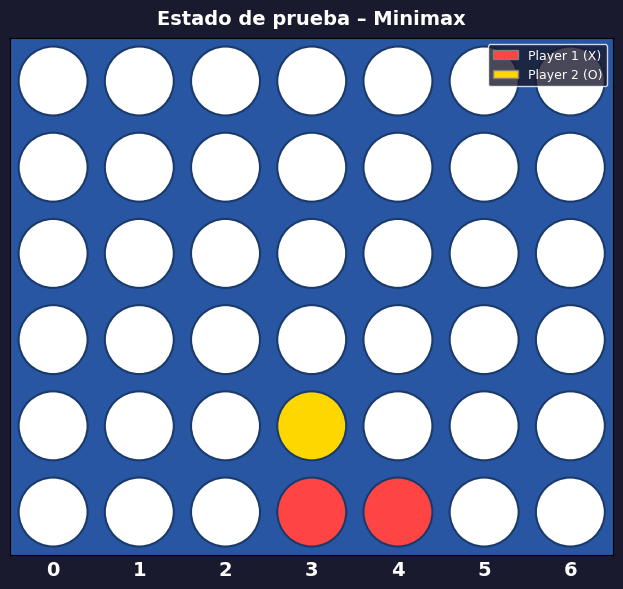

Turno de: O (P2)
Minimax (d=4) recomienda columna: 2
Nodos visitados: 2800


In [14]:
# ============================================================
# Agente Minimax (sin poda) – Profundidad limitada d=3 o d=4
# ============================================================

class MinimaxAgent:
    """Agente que usa Minimax puro (sin poda alfa-beta)."""

    def __init__(self, ai_player=Connect4.PLAYER2, depth=4):
        self.ai_player = ai_player
        self.opponent = Connect4.PLAYER1 if ai_player == Connect4.PLAYER2 else Connect4.PLAYER2
        self.depth = depth
        self.nodes_visited = 0

    def get_best_move(self, game):
        """Retorna la mejor columna usando Minimax."""
        self.nodes_visited = 0
        best_score = -float('inf')
        best_col = random.choice(game.actions())

        for col in game.actions():
            row = game.drop_piece(col)
            score = self._minimax(game, self.depth - 1, False)
            game.undo_move(col, row)
            if score > best_score:
                best_score = score
                best_col = col

        return best_col, self.nodes_visited

    def _minimax(self, game, depth, is_maximizing):
        """Algoritmo Minimax recursivo."""
        self.nodes_visited += 1

        if game.is_terminal():
            return game.get_terminal_score(self.ai_player)

        if depth == 0:
            return 0  # Sin heurística por ahora (se agrega en Task 2.3)

        if is_maximizing:
            max_eval = -float('inf')
            for col in game.actions():
                row = game.drop_piece(col)
                eval_score = self._minimax(game, depth - 1, False)
                game.undo_move(col, row)
                max_eval = max(max_eval, eval_score)
            return max_eval
        else:
            min_eval = float('inf')
            for col in game.actions():
                row = game.drop_piece(col)
                eval_score = self._minimax(game, depth - 1, True)
                game.undo_move(col, row)
                min_eval = min(min_eval, eval_score)
            return min_eval


# --- Demo Minimax ---
game = Connect4()
agent = MinimaxAgent(ai_player=Connect4.PLAYER2, depth=4)

# Simular algunos movimientos iniciales
game.drop_piece(3)  # Player 1
game.drop_piece(3)  # Player 2
game.drop_piece(4)  # Player 1

game.display_board(title="Estado de prueba – Minimax")
print(f"Turno de: {'X (P1)' if game.current_player == 1 else 'O (P2)'}")

best_col, nodes = agent.get_best_move(game)
print(f"Minimax (d=4) recomienda columna: {best_col}")
print(f"Nodos visitados: {nodes}")

---
## Task 2.2 – Poda Alfa-Beta

Se modifica la función recursiva para pasar y actualizar los valores α y β, podando ramas que no pueden mejorar el resultado.

In [15]:
# ============================================================
# Agente Minimax con Poda Alfa-Beta
# ============================================================

class AlphaBetaAgent:
    """Agente que usa Minimax con poda Alfa-Beta."""

    def __init__(self, ai_player=Connect4.PLAYER2, depth=4):
        self.ai_player = ai_player
        self.opponent = Connect4.PLAYER1 if ai_player == Connect4.PLAYER2 else Connect4.PLAYER2
        self.depth = depth
        self.nodes_visited = 0

    def get_best_move(self, game):
        """Retorna la mejor columna usando Minimax con poda alfa-beta."""
        self.nodes_visited = 0
        best_score = -float('inf')
        best_col = random.choice(game.actions())
        alpha = -float('inf')
        beta = float('inf')

        for col in game.actions():
            row = game.drop_piece(col)
            score = self._alphabeta(game, self.depth - 1, alpha, beta, False)
            game.undo_move(col, row)
            if score > best_score:
                best_score = score
                best_col = col
            alpha = max(alpha, best_score)

        return best_col, self.nodes_visited

    def _alphabeta(self, game, depth, alpha, beta, is_maximizing):
        """Algoritmo Minimax con poda Alfa-Beta."""
        self.nodes_visited += 1

        if game.is_terminal():
            return game.get_terminal_score(self.ai_player)

        if depth == 0:
            return 0  # Sin heurística por ahora

        if is_maximizing:
            max_eval = -float('inf')
            for col in game.actions():
                row = game.drop_piece(col)
                eval_score = self._alphabeta(game, depth - 1, alpha, beta, False)
                game.undo_move(col, row)
                max_eval = max(max_eval, eval_score)
                alpha = max(alpha, eval_score)
                if beta <= alpha:
                    break  # Poda β
            return max_eval
        else:
            min_eval = float('inf')
            for col in game.actions():
                row = game.drop_piece(col)
                eval_score = self._alphabeta(game, depth - 1, alpha, beta, True)
                game.undo_move(col, row)
                min_eval = min(min_eval, eval_score)
                beta = min(beta, eval_score)
                if beta <= alpha:
                    break  # Poda α
            return min_eval


print("AlphaBetaAgent definido correctamente.")

AlphaBetaAgent definido correctamente.


In [16]:
# ============================================================
# Comparación: Minimax puro vs Alfa-Beta (mismo estado)
# ============================================================

# Crear un estado de prueba
test_game = Connect4()
test_game.drop_piece(3)  # P1
test_game.drop_piece(2)  # P2
test_game.drop_piece(3)  # P1
test_game.drop_piece(4)  # P2
test_game.drop_piece(5)  # P1

test_game.print_board()
print(f"Turno de: {'X (P1)' if test_game.current_player == 1 else 'O (P2)'}")
print("=" * 50)

# Minimax puro
minimax_agent = MinimaxAgent(ai_player=Connect4.PLAYER2, depth=4)
game_copy1 = test_game.copy()
t0 = time.time()
col_mm, nodes_mm = minimax_agent.get_best_move(game_copy1)
t1 = time.time()
print(f"Minimax puro (d=4):")
print(f"  Mejor columna: {col_mm}")
print(f"  Nodos visitados: {nodes_mm:,}")
print(f"  Tiempo: {t1 - t0:.4f} s")

print()

# Alfa-Beta
ab_agent = AlphaBetaAgent(ai_player=Connect4.PLAYER2, depth=4)
game_copy2 = test_game.copy()
t0 = time.time()
col_ab, nodes_ab = ab_agent.get_best_move(game_copy2)
t1 = time.time()
print(f"Alfa-Beta (d=4):")
print(f"  Mejor columna: {col_ab}")
print(f"  Nodos visitados: {nodes_ab:,}")
print(f"  Tiempo: {t1 - t0:.4f} s")

print()
reduction = (1 - nodes_ab / nodes_mm) * 100 if nodes_mm > 0 else 0
print(f"Reducción de nodos con Alfa-Beta: {reduction:.1f}%")


. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . O X O X .
0 1 2 3 4 5 6

Turno de: O (P2)
Minimax puro (d=4):
  Mejor columna: 0
  Nodos visitados: 2,800
  Tiempo: 0.1422 s

Alfa-Beta (d=4):
  Mejor columna: 0
  Nodos visitados: 190
  Tiempo: 0.0086 s

Reducción de nodos con Alfa-Beta: 93.2%


---
## Task 2.3 – Función heurística de evaluación

### Estrategia heurística implementada:

1. **Control del centro:** La columna central (col 3) es la más estratégica. Se otorgan +3 puntos por cada ficha propia en el centro.
2. **Ventanas de 4 posiciones:** Se evalúan todas las ventanas posibles de 4 casillas (horizontal, vertical, diagonal). Puntajes:
   - **4 fichas propias** → +1000 (victoria)
   - **3 fichas propias + 1 vacía** → +50 (amenaza fuerte)
   - **2 fichas propias + 2 vacías** → +10 (potencial)
   - **3 fichas del oponente + 1 vacía** → −80 (bloquear urgente, penalización mayor para priorizar defensa)

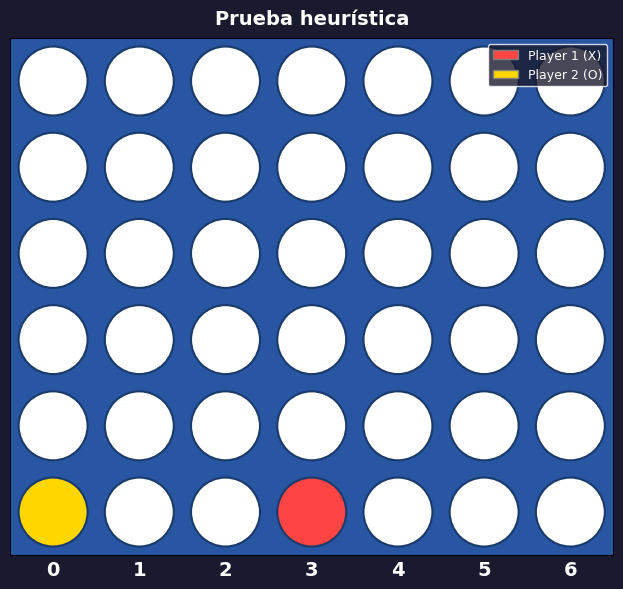

Evaluación para P2 (O): 0
Evaluación para P1 (X): 3


In [17]:
# ============================================================
# Función heurística de evaluación
# ============================================================

def evaluate_window(window, ai_player):
    """Evalúa una ventana de 4 posiciones."""
    opponent = Connect4.PLAYER1 if ai_player == Connect4.PLAYER2 else Connect4.PLAYER2
    score = 0

    ai_count = np.count_nonzero(window == ai_player)
    opp_count = np.count_nonzero(window == opponent)
    empty_count = np.count_nonzero(window == Connect4.EMPTY)

    if ai_count == 4:
        score += 1000
    elif ai_count == 3 and empty_count == 1:
        score += 50
    elif ai_count == 2 and empty_count == 2:
        score += 10

    if opp_count == 3 and empty_count == 1:
        score -= 80  # Penalización alta para priorizar bloqueo
    elif opp_count == 2 and empty_count == 2:
        score -= 5

    return score


def evaluate(game, ai_player):
    """
    Evalúa el tablero completo desde la perspectiva de ai_player.

    Estrategia:
    - Control del centro (+3 por ficha en columna central)
    - Evaluación de todas las ventanas de 4 en horizontal, vertical y diagonales
    """
    board = game.board
    score = 0

    # 1. Control del centro
    center_col = board[:, Connect4.COLS // 2]
    center_count = np.count_nonzero(center_col == ai_player)
    score += center_count * 3

    # 2. Evaluación horizontal
    for r in range(Connect4.ROWS):
        for c in range(Connect4.COLS - 3):
            window = board[r, c:c + 4]
            score += evaluate_window(window, ai_player)

    # 3. Evaluación vertical
    for c in range(Connect4.COLS):
        for r in range(Connect4.ROWS - 3):
            window = board[r:r + 4, c]
            score += evaluate_window(window, ai_player)

    # 4. Diagonal ↘
    for r in range(Connect4.ROWS - 3):
        for c in range(Connect4.COLS - 3):
            window = np.array([board[r + i][c + i] for i in range(4)])
            score += evaluate_window(window, ai_player)

    # 5. Diagonal ↗
    for r in range(3, Connect4.ROWS):
        for c in range(Connect4.COLS - 3):
            window = np.array([board[r - i][c + i] for i in range(4)])
            score += evaluate_window(window, ai_player)

    return score


# --- Prueba de la heurística ---
test_game2 = Connect4()
test_game2.drop_piece(3)  # P1 centro
test_game2.drop_piece(0)  # P2 esquina
test_game2.display_board(title="Prueba heurística")
print(f"Evaluación para P2 (O): {evaluate(test_game2, Connect4.PLAYER2)}")
print(f"Evaluación para P1 (X): {evaluate(test_game2, Connect4.PLAYER1)}")

In [18]:
# ============================================================
# Agente Alfa-Beta con heurística (profundidad 5-6)
# ============================================================

class SmartAlphaBetaAgent:
    """Agente Alfa-Beta con función heurística para nodos hoja."""

    def __init__(self, ai_player=Connect4.PLAYER2, depth=6):
        self.ai_player = ai_player
        self.opponent = Connect4.PLAYER1 if ai_player == Connect4.PLAYER2 else Connect4.PLAYER2
        self.depth = depth
        self.nodes_visited = 0

    def get_best_move(self, game):
        """Retorna la mejor columna usando Alfa-Beta con heurística."""
        self.nodes_visited = 0
        best_score = -float('inf')
        best_col = random.choice(game.actions())
        alpha = -float('inf')
        beta = float('inf')

        # Ordenar movimientos: priorizar columna central (mejora la poda)
        actions = game.actions()
        center = Connect4.COLS // 2
        actions.sort(key=lambda c: abs(c - center))

        for col in actions:
            row = game.drop_piece(col)
            score = self._alphabeta(game, self.depth - 1, alpha, beta, False)
            game.undo_move(col, row)
            if score > best_score:
                best_score = score
                best_col = col
            alpha = max(alpha, best_score)

        return best_col, self.nodes_visited

    def _alphabeta(self, game, depth, alpha, beta, is_maximizing):
        """Minimax con poda Alfa-Beta y evaluación heurística en hojas."""
        self.nodes_visited += 1

        if game.is_terminal():
            return game.get_terminal_score(self.ai_player)

        if depth == 0:
            return evaluate(game, self.ai_player)  # ¡Heurística en nodos hoja!

        # Ordenar acciones para mejorar poda
        actions = game.actions()
        center = Connect4.COLS // 2
        actions.sort(key=lambda c: abs(c - center))

        if is_maximizing:
            max_eval = -float('inf')
            for col in actions:
                row = game.drop_piece(col)
                eval_score = self._alphabeta(game, depth - 1, alpha, beta, False)
                game.undo_move(col, row)
                max_eval = max(max_eval, eval_score)
                alpha = max(alpha, eval_score)
                if beta <= alpha:
                    break
            return max_eval
        else:
            min_eval = float('inf')
            for col in actions:
                row = game.drop_piece(col)
                eval_score = self._alphabeta(game, depth - 1, alpha, beta, True)
                game.undo_move(col, row)
                min_eval = min(min_eval, eval_score)
                beta = min(beta, eval_score)
                if beta <= alpha:
                    break
            return min_eval


print("SmartAlphaBetaAgent (con heurística) definido correctamente.")

SmartAlphaBetaAgent (con heurística) definido correctamente.


---
## Partida: IA (Alfa-Beta, d=6) vs Agente Aleatorio

La IA juega como **O (Player 2)** y el agente aleatorio como **X (Player 1)**.

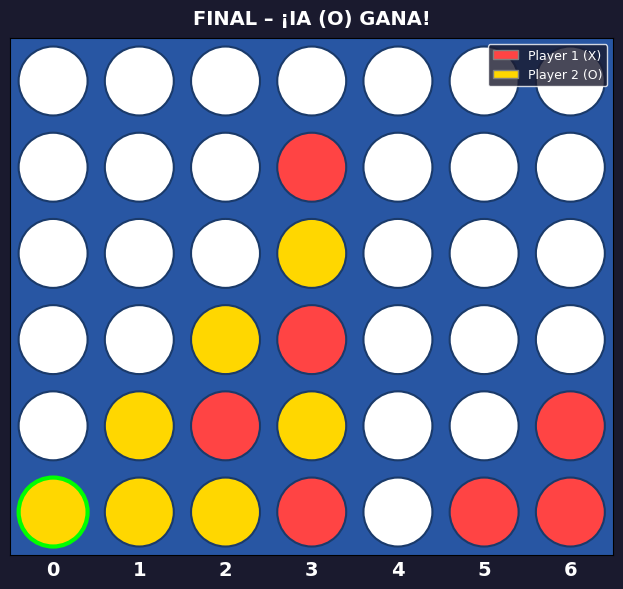

Resultado: ¡IA (O) GANA!  |  Movimientos: 14


In [19]:
# ============================================================
# IA vs Agente Aleatorio
# ============================================================

def play_ai_vs_random(ai_depth=6, verbose=True, visual=True):
    """Juega una partida: IA (Player 2, O) vs Random (Player 1, X)."""
    game = Connect4()
    ai_agent = SmartAlphaBetaAgent(ai_player=Connect4.PLAYER2, depth=ai_depth)
    move_count = 0
    last_move = None

    while not game.is_terminal():
        if game.current_player == Connect4.PLAYER1:
            # Agente aleatorio
            col = random.choice(game.actions())
            row = game.drop_piece(col)
            last_move = (row, col)
            if verbose:
                print(f"Aleatorio (X) juega columna: {col}")
        else:
            # IA Alfa-Beta
            col, nodes = ai_agent.get_best_move(game)
            row = game.drop_piece(col)
            last_move = (row, col)
            if verbose:
                print(f"IA (O) juega columna: {col}  [nodos: {nodes:,}]")

        move_count += 1
        if verbose and visual:
            clear_output(wait=True)
            game.display_board(title=f"Movimiento #{move_count}", last_move=last_move)
        elif verbose:
            game.print_board()

    # Resultado
    if game.check_winner(Connect4.PLAYER2):
        result = "¡IA (O) GANA!"
    elif game.check_winner(Connect4.PLAYER1):
        result = "Aleatorio (X) gana."
    else:
        result = "Empate."

    if verbose and visual:
        clear_output(wait=True)
        game.display_board(title=f"FINAL – {result}", last_move=last_move)
    
    print(f"Resultado: {result}  |  Movimientos: {move_count}")
    return result


result = play_ai_vs_random(ai_depth=6, verbose=True, visual=True)

In [20]:
# ============================================================
# Estadísticas: 10 partidas IA vs Aleatorio
# ============================================================

wins_ia = 0
wins_random = 0
draws = 0

print("Jugando 10 partidas IA (d=6) vs Aleatorio...\n")
for i in range(10):
    result = play_ai_vs_random(ai_depth=6, verbose=False, visual=False)
    print(f"  Partida {i+1}: {result}")
    if "IA" in result:
        wins_ia += 1
    elif "Aleatorio" in result:
        wins_random += 1
    else:
        draws += 1

print(f"\n{'='*40}")
print(f"Resultados en 10 partidas:")
print(f"  IA gana:        {wins_ia}/10")
print(f"  Aleatorio gana: {wins_random}/10")
print(f"  Empates:        {draws}/10")

Jugando 10 partidas IA (d=6) vs Aleatorio...

Resultado: ¡IA (O) GANA!  |  Movimientos: 8
  Partida 1: ¡IA (O) GANA!
Resultado: ¡IA (O) GANA!  |  Movimientos: 10
  Partida 2: ¡IA (O) GANA!
Resultado: ¡IA (O) GANA!  |  Movimientos: 8
  Partida 3: ¡IA (O) GANA!
Resultado: ¡IA (O) GANA!  |  Movimientos: 8
  Partida 4: ¡IA (O) GANA!
Resultado: ¡IA (O) GANA!  |  Movimientos: 20
  Partida 5: ¡IA (O) GANA!
Resultado: ¡IA (O) GANA!  |  Movimientos: 12
  Partida 6: ¡IA (O) GANA!
Resultado: ¡IA (O) GANA!  |  Movimientos: 8
  Partida 7: ¡IA (O) GANA!
Resultado: ¡IA (O) GANA!  |  Movimientos: 16
  Partida 8: ¡IA (O) GANA!
Resultado: ¡IA (O) GANA!  |  Movimientos: 16
  Partida 9: ¡IA (O) GANA!
Resultado: ¡IA (O) GANA!  |  Movimientos: 14
  Partida 10: ¡IA (O) GANA!

Resultados en 10 partidas:
  IA gana:        10/10
  Aleatorio gana: 0/10
  Empates:        0/10


---
## Partida interactiva: Humano vs IA

Juega como **X (Player 1)**. La IA juega como **O (Player 2)** con Alfa-Beta (d=6).
Ingresa el número de columna (0-6) cuando sea tu turno.

C:\Users\Admin\AppData\Local\Temp\ipykernel_27652\2921073346.py:135: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\UVG\IA\IA\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


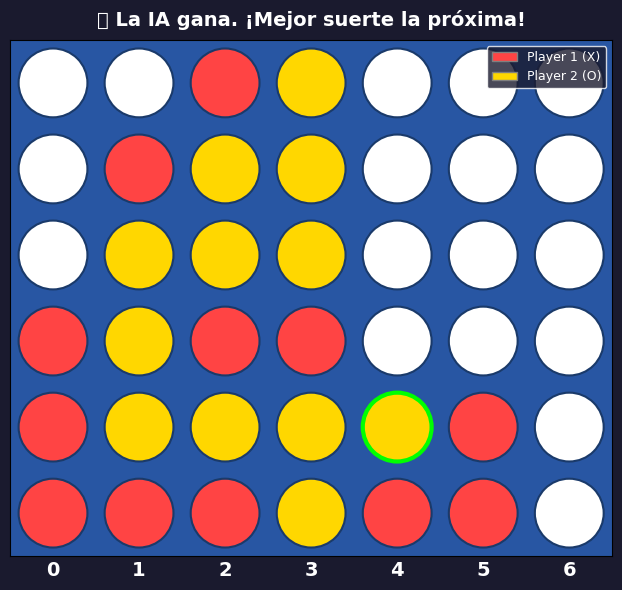

In [ ]:
# ============================================================
# Humano (X) vs IA (O) – Partida interactiva con tablero visual
# ============================================================

def play_human_vs_ai(ai_depth=6):
    """Partida interactiva: Humano (Player 1, X) vs IA (Player 2, O)."""
    game = Connect4()
    ai_agent = SmartAlphaBetaAgent(ai_player=Connect4.PLAYER2, depth=ai_depth)
    last_move = None

    print("¡Connect Four! Tú eres ROJO (X), la IA es AMARILLO (O).")
    print("Ingresa el número de columna (0-6).\n")
    game.display_board(title="¡Tu turno!", last_move=last_move)

    while not game.is_terminal():
        if game.current_player == Connect4.PLAYER1:
            # Turno del humano
            valid = game.actions()
            while True:
                try:
                    col = int(input(f"Tu turno (columnas válidas {valid}): "))
                    if col in valid:
                        break
                    print(f"  Columna {col} no es válida. Intenta de nuevo.")
                except ValueError:
                    print("  Ingresa un número entre 0 y 6.")
            row = game.drop_piece(col)
            last_move = (row, col)
            clear_output(wait=True)
            game.display_board(title=f"Tú (X) jugaste columna {col}", last_move=last_move)
        else:
            # Turno de la IA
            print("La IA está pensando...")
            t0 = time.time()
            col, nodes = ai_agent.get_best_move(game)
            t1 = time.time()
            row = game.drop_piece(col)
            last_move = (row, col)
            clear_output(wait=True)
            game.display_board(
                title=f"IA (O) jugó columna {col}  [{nodes:,} nodos, {t1-t0:.2f}s]",
                last_move=last_move
            )

    # Resultado final
    clear_output(wait=True)
    if game.check_winner(Connect4.PLAYER1):
        game.display_board(title="🎉 ¡GANASTE! ¡Felicidades!", last_move=last_move)
    elif game.check_winner(Connect4.PLAYER2):
        game.display_board(title="🤖 La IA gana. ¡Mejor suerte la próxima!", last_move=last_move)
    else:
        game.display_board(title="🤝 ¡Empate!", last_move=last_move)


# Descomenta la siguiente línea para jugar:
# play_human_vs_ai(ai_depth=6)